# ILO Child Labour Profiling 

1. Still only use 'fs.sav + hh.sav'.

2. Keep chosen variables

3. Convert the hazard yes/no variable to binary first: '1=Yes -> 1', '2=No -> 0', '8/9 -> missing'.

4. Combine 'CL5 + CL6A-CL6X' into 'hazard_index' to avoid dangerous labor variables repeatedly dominating the model.

5. Using one-hot encoding for categorical variables




## 1. Import packages and set paths



In [40]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pyreadstat
except ImportError:
    print("Please install pyreadstat first: pip install pyreadstat")
    raise

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

DATA_DIR = Path("/Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana")
OUTPUT_DIR = DATA_DIR / "outputs_selected_features"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


print("Data path:", DATA_DIR)

Data path: /Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana


## 2. Load `fs.sav` and `hh.sav`


In [41]:
fs, meta_fs = pyreadstat.read_sav(DATA_DIR / "fs.sav", apply_value_formats=False)
hh, meta_hh = pyreadstat.read_sav(DATA_DIR / "hh.sav", apply_value_formats=False)

print("fs shape:", fs.shape)
print("hh shape:", hh.shape)

# Combine labels from fs and hh.
labels = {}
labels.update(meta_hh.column_names_to_labels)
labels.update(meta_fs.column_names_to_labels)

# Household variables needed for your selected features.
hh_needed = ["HH1", "HH2", "HHSEX", "HHAGE", "helevel", "wscore"]
hh_keep = [c for c in hh_needed if c in hh.columns]

# Avoid duplicate columns if some variables already exist in fs.
hh_keep_final = ["HH1", "HH2"]
for c in hh_keep:
    if c in ["HH1", "HH2"]:
        continue
    if c not in fs.columns:
        hh_keep_final.append(c)

merged = fs.merge(
    hh[hh_keep_final],
    on=["HH1", "HH2"],
    how="left"
)

print("merged shape:", merged.shape)
print("household columns merged:", hh_keep_final)

fs shape: (40617, 268)
hh shape: (64400, 273)
merged shape: (40617, 271)
household columns merged: ['HH1', 'HH2', 'HHSEX', 'HHAGE', 'helevel']


## 3. Select the features 


In [42]:
features = [
    # Child labour
    "CL3",    # hours worked in the past week
    "CL5",    # hazardous work: dangerous tools or heavy machinery
    "CL6A",   # hazardous work: exposed to dust, fumes, or gas
    "CL6B",   # hazardous work: exposed to extreme temperatures or humidity
    "CL6C",   # hazardous work: exposed to loud noise or vibration
    "CL6D",   # hazardous work: required to work at heights
    "CL6E",   # hazardous work: required to work with chemicals
    "CL6X",   # hazardous work: exposed to other risks

    # Child demographics
    "CB3",    # age; if FSAGE exists, we use it only to fill missing CB3
    "HL4",    # sex

    # Education
    "ED5A",     # highest level of education attended
    "ED5B",     # highest grade attended at ED5A
    "fselevel", # child's education

    # Socio-economic
    "wscore",   # combined wealth score

    # Household head
    "HHSEX",    # sex of household head
    "HHAGE",    # age of household head
    "helevel"   # education of household head
]

available_features = [f for f in features if f in merged.columns]
missing_features = [f for f in features if f not in merged.columns]

print("Available features:", available_features)
print("Missing features:", missing_features)

df_raw = merged[available_features].copy()
df_raw = df_raw.replace("", np.nan)

# Add weight only for summaries, not as a clustering feature.
weight_col = "fsweight" if "fsweight" in merged.columns else None
print("weight column:", weight_col)

Available features: ['CL3', 'CL5', 'CL6A', 'CL6B', 'CL6C', 'CL6D', 'CL6E', 'CL6X', 'CB3', 'HL4', 'ED5A', 'ED5B', 'fselevel', 'wscore', 'HHSEX', 'HHAGE', 'helevel']
Missing features: []
weight column: fsweight


## 4. Clean variables simply and correctly


In [43]:
df = df_raw.copy()

def yes_no_to_binary(s):
    """Convert common MICS yes/no coding to 1/0."""
    return pd.to_numeric(s, errors="coerce").replace({
        1: 1,
        2: 0,
        8: np.nan,
        9: np.nan
    })

def zscore(s):
    """Simple z-score. If standard deviation is zero, return zeros."""
    s = pd.to_numeric(s, errors="coerce")
    sd = s.std(ddof=0)
    if sd == 0 or pd.isna(sd):
        return pd.Series(0, index=s.index)
    return (s - s.mean()) / sd

# 1) Clean age: use CB3; if FSAGE exists, use it only to fill missing CB3.
if "CB3" in df.columns:
    df["CB3"] = pd.to_numeric(df["CB3"], errors="coerce")
    if "FSAGE" in merged.columns:
        df["CB3"] = df["CB3"].fillna(pd.to_numeric(merged["FSAGE"], errors="coerce"))

# 2) Clean hours worked.
# For CL3, missing often means the child did not do the activity or the value was skipped.
# We keep this simple and set missing to 0 after removing special missing codes.
if "CL3" in df.columns:
    df["CL3"] = (
        pd.to_numeric(df["CL3"], errors="coerce")
        .replace({97: np.nan, 98: np.nan, 99: np.nan})
        .fillna(0)
        .clip(lower=0)
    )

# 3) Recode hazardous work variables and create hazard_index.
hazard_cols = ["CL5", "CL6A", "CL6B", "CL6C", "CL6D", "CL6E", "CL6X"]
existing_hazard_cols = [c for c in hazard_cols if c in df.columns]

for col in existing_hazard_cols:
    df[col] = yes_no_to_binary(df[col])

# Count how many hazardous conditions apply.
df["hazard_index"] = df[existing_hazard_cols].fillna(0).sum(axis=1)
df["any_hazard"] = (df["hazard_index"] > 0).astype(int)

# Drop individual hazard columns to avoid over-weighting the same concept.
df = df.drop(columns=existing_hazard_cols)

# 4) Treat these variables as categorical.
# One-hot encoding later is better than .cat.codes because codes can create fake numeric distance.
categorical_cols = ["HL4", "HHSEX", "ED5A", "fselevel", "helevel"]
categorical_cols = [c for c in categorical_cols if c in df.columns]

for col in categorical_cols:
    df[col] = df[col].astype("string").fillna("Missing")

# 5) All remaining non-categorical variables should be numeric.
for col in df.columns:
    if col not in categorical_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        med = df[col].median()
        if pd.isna(med):
            med = 0
        df[col] = df[col].fillna(med)

print("Cleaned data shape:", df.shape)
print("Categorical columns:", categorical_cols)
print("Final columns before one-hot:")
print(df.columns.tolist())

df.head()

Cleaned data shape: (40617, 12)
Categorical columns: ['HL4', 'HHSEX', 'ED5A', 'fselevel', 'helevel']
Final columns before one-hot:
['CL3', 'CB3', 'HL4', 'ED5A', 'ED5B', 'fselevel', 'wscore', 'HHSEX', 'HHAGE', 'helevel', 'hazard_index', 'any_hazard']


,CL3,CB3,HL4,ED5A,ED5B,fselevel,wscore,HHSEX,HHAGE,helevel,hazard_index,any_hazard
0,0.0,9.0,1.0,3.0,12.0,1.0,-0.100223,1.0,38.0,3.0,0.0,0
1,0.0,10.0,2.0,1.0,1.0,1.0,-0.139947,1.0,35.0,1.0,0.0,0
2,0.0,13.0,2.0,2.0,8.0,2.0,1.152283,1.0,56.0,1.0,0.0,0
3,0.0,11.0,1.0,2.0,6.0,1.0,1.225890,1.0,40.0,1.0,0.0,0
4,0.0,6.0,1.0,Missing,7.0,0.0,-0.316737,1.0,66.0,0.0,0.0,0


## 5. feature labels



In [44]:
feature_labels = {f: labels.get(f, "No description available") for f in available_features}
feature_labels["hazard_index"] = "Number of hazardous work conditions, based on CL5 and CL6A-CL6X"
feature_labels["any_hazard"] = "Whether the child has at least one hazardous work condition"

feature_labels_df = pd.DataFrame({
    "feature": list(feature_labels.keys()),
    "label": list(feature_labels.values())
})

feature_labels_df.to_csv(OUTPUT_DIR / "feature_labels.csv", index=False)
feature_labels_df

,feature,label
0,CL3,Hours worked in past week
1,CL5,Activities required working with dangerous too...
2,CL6A,"Description of work: exposed to dust, fumes, ..."
3,CL6B,Description of work: exposed to extreme tempe...
4,CL6C,Description of work: exposed to loud noise or...
5,CL6D,Description of work: required to work at heights
6,CL6E,Description of work: required to work with ch...
7,CL6X,Description of work: exposed to other
8,CB3,Age of child
9,HL4,Sex


## 6. Prepare data for clustering

In [45]:
X = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
X = X.replace([np.inf, -np.inf], np.nan)

# Fill any remaining missing values.
for col in X.columns:
    if X[col].isna().any():
        med = X[col].median()
        if pd.isna(med):
            med = 0
        X[col] = X[col].fillna(med)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Model matrix shape:", X.shape)
print("Number of model features after one-hot:", len(X.columns))

pd.Series(X.columns, name="model_feature").to_csv(OUTPUT_DIR / "model_matrix_columns.csv", index=False)

Model matrix shape: (40617, 29)
Number of model features after one-hot: 29


## 7. Compare number of clusters
- The taller the silhouette, the better.
- The lower the -Davies-Bouldin, the better.
- The cluster size should not be too small.



In [46]:
scores = []
K_range = range(2, 9)

for k_test in K_range:
    model = KMeans(n_clusters=k_test, random_state=42, n_init=20)
    labels_k = model.fit_predict(X_scaled)
    counts = pd.Series(labels_k).value_counts()
    
    scores.append({
        "k": k_test,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels_k),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels_k),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels_k),
        "min_cluster_size": counts.min(),
        "max_cluster_size": counts.max()
    })

scores_df = pd.DataFrame(scores)
scores_df.to_csv(OUTPUT_DIR / "cluster_model_scores.csv", index=False)
scores_df

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size
0,2,1.081415e+06,0.130050,3623.472315,2.657149,10815,29802
1,3,9.987615e+05,0.149269,3642.134846,2.277169,2916,27242
2,4,9.384801e+05,0.133382,3453.553687,2.254346,2837,19718
3,5,8.771272e+05,0.125168,3481.451949,2.094028,2807,15139
4,6,8.271623e+05,0.146279,3443.951674,1.926944,1314,15155
5,7,7.811647e+05,0.171592,3437.417141,1.640894,7,10424
6,8,7.555560e+05,0.174751,3242.776078,1.673848,7,10297


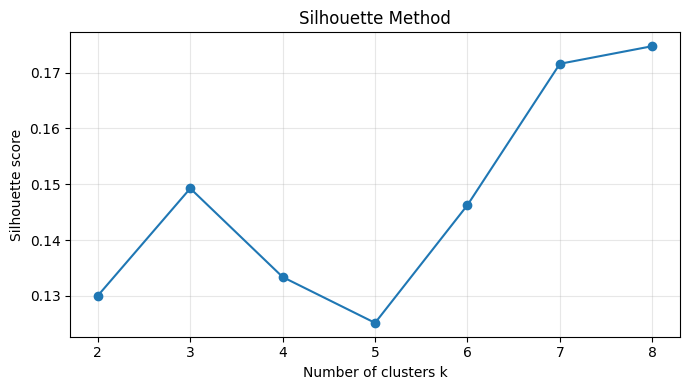

In [47]:

plt.figure(figsize=(7, 4))
plt.plot(scores_df["k"], scores_df["silhouette"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Method")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_selection_silhouette.png", dpi=200)
plt.show()

## 8. Fit final KMeans model



In [48]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
cluster_labels = kmeans.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered["cluster"] = cluster_labels

# Add survey weight for summaries if available.
if weight_col is not None:
    df_clustered["fsweight"] = pd.to_numeric(merged.loc[df_clustered.index, weight_col], errors="coerce").fillna(1)
else:
    df_clustered["fsweight"] = 1

print(df_clustered["cluster"].value_counts().sort_index())

df_clustered.to_csv(OUTPUT_DIR / "processed_child_profiles.csv", index=False)

cluster
0    10459
1     2916
2    27242
Name: count, dtype: int64


## 9. Basic cluster summaries



In [49]:
numeric_summary_cols = [c for c in ["CL3", "CB3", "ED5B", "wscore", "HHAGE", "hazard_index", "any_hazard"] if c in df_clustered.columns]

cluster_numeric_summary = df_clustered.groupby("cluster")[numeric_summary_cols].mean().round(3)
cluster_numeric_summary["n"] = df_clustered.groupby("cluster").size()
cluster_numeric_summary = cluster_numeric_summary.reset_index()

cluster_numeric_summary.to_csv(OUTPUT_DIR / "cluster_numeric_summary.csv", index=False)
cluster_numeric_summary

,cluster,CL3,CB3,ED5B,wscore,HHAGE,hazard_index,any_hazard,n
0,0,0.211,10.003,10.808,0.692,44.530,0.003,0.003,10459
1,1,21.313,14.067,6.207,-0.411,47.953,2.183,0.948,2916
2,2,0.646,10.990,5.953,-0.235,45.686,0.000,0.000,27242


In [50]:
# Categorical summaries: distribution within each cluster.
all_cat_summaries = []

for col in categorical_cols:
    tmp = pd.crosstab(
        df_clustered["cluster"],
        df_clustered[col],
        normalize="index"
    ).round(3)
    tmp["variable"] = col
    tmp = tmp.reset_index()
    all_cat_summaries.append(tmp)

if all_cat_summaries:
    cluster_categorical_summary = pd.concat(all_cat_summaries, ignore_index=True)
    cluster_categorical_summary.to_csv(OUTPUT_DIR / "cluster_categorical_summary.csv", index=False)
    display(cluster_categorical_summary)
else:
    print("No categorical columns found.")

,cluster,1.0,2.0,variable,0.0,3.0,4.0,8.0,Missing,9.0
0,0,0.502,0.498,HL4,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0.792,0.208,HL4,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0.491,0.509,HL4,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0.878,0.122,HHSEX,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0.909,0.091,HHSEX,NaN,NaN,NaN,NaN,NaN,NaN
5,2,0.898,0.102,HHSEX,NaN,NaN,NaN,NaN,NaN,NaN
6,0,0.001,0.017,ED5A,0.000,0.854,0.125,0.001,0.003,NaN
7,1,0.328,0.136,ED5A,0.004,0.077,0.001,0.000,0.454,NaN
8,2,0.381,0.269,ED5A,0.004,0.000,0.000,0.000,0.345,NaN
9,0,0.458,0.337,fselevel,0.140,0.034,NaN,NaN,0.031,0.000


## 10. Weighted summary


In [51]:
def weighted_mean(group, col):
    x = pd.to_numeric(group[col], errors="coerce")
    w = pd.to_numeric(group["fsweight"], errors="coerce").fillna(1)
    ok = x.notna() & w.notna()
    if ok.sum() == 0 or w[ok].sum() == 0:
        return np.nan
    return np.average(x[ok], weights=w[ok])

weighted_rows = []
total_weight = df_clustered["fsweight"].sum()

for cluster_id, g in df_clustered.groupby("cluster"):
    row = {
        "cluster": cluster_id,
        "n_unweighted": len(g),
        "weighted_size": g["fsweight"].sum(),
        "weighted_share": g["fsweight"].sum() / total_weight
    }
    for col in numeric_summary_cols:
        row[f"weighted_mean_{col}"] = weighted_mean(g, col)
    weighted_rows.append(row)

weighted_summary = pd.DataFrame(weighted_rows).round(3)
weighted_summary.to_csv(OUTPUT_DIR / "cluster_weighted_summary.csv", index=False)
weighted_summary

,cluster,n_unweighted,weighted_size,weighted_share,weighted_mean_CL3,weighted_mean_CB3,weighted_mean_ED5B,weighted_mean_wscore,weighted_mean_HHAGE,weighted_mean_hazard_index,weighted_mean_any_hazard
0,0,10459,16546.222,0.248,0.275,10.184,10.776,0.888,44.888,0.003,0.003
1,1,2916,5102.596,0.076,24.099,14.107,6.182,-0.353,47.408,2.120,0.925
2,2,27242,45055.805,0.675,0.743,10.982,5.938,-0.158,45.578,0.000,0.000


## 11. Visualize clusters with PCA


Explained variance ratio: [0.11361422 0.08865213]


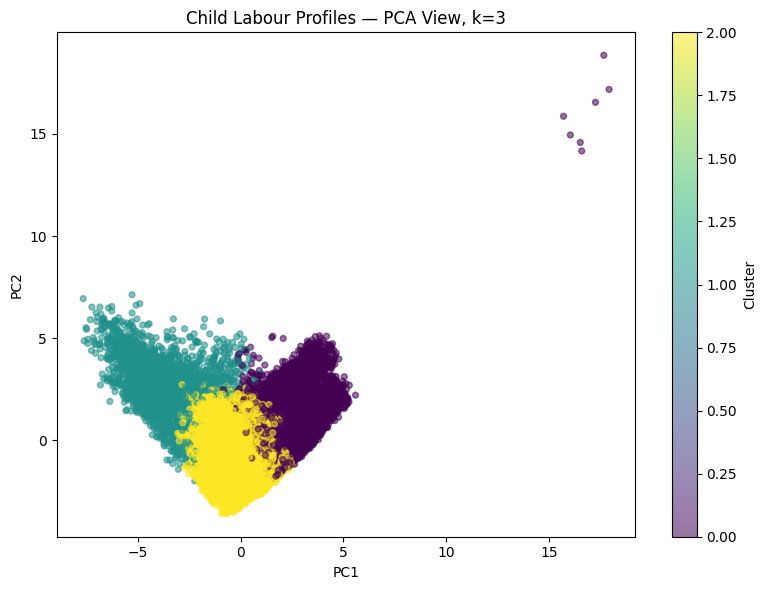

In [52]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_clustered["PC1"] = X_pca[:, 0]
df_clustered["PC2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_clustered["PC1"],
    df_clustered["PC2"],
    c=df_clustered["cluster"],
    alpha=0.55,
    s=18
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Child Labour Profiles — PCA View, k={k}")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_pca.png", dpi=200)
plt.show()

## 12. Simple policy-facing bubble chart

- Horizontal axis: social vulnerability, temporarily represented by '-wscore', the further to the right, the poorer/more vulnerable;
- Vertical axis: labour exposure, denoted by 'CL3 + hazard_index', the higher the Labour risk;

- Bubble size: Number of cluster members.


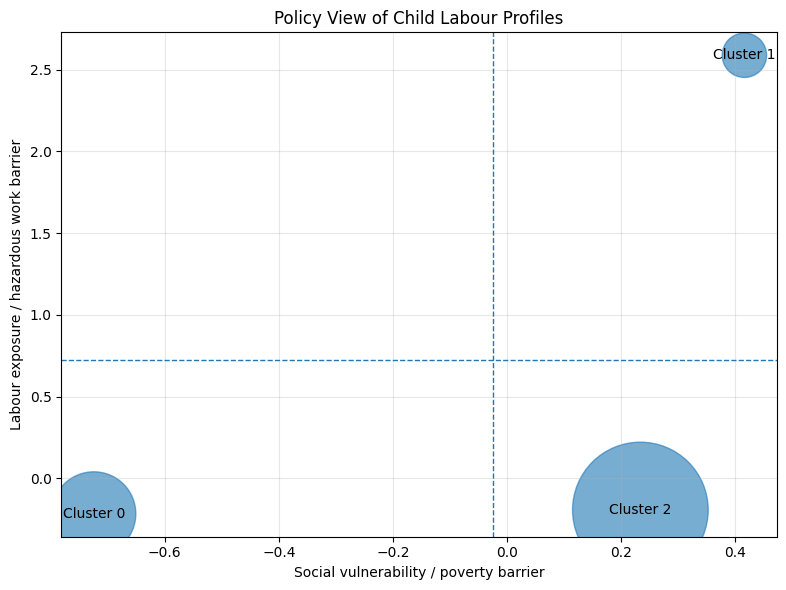

,cluster,social_barrier,labour_barrier,size,mean_age,mean_hours,mean_hazard
0,0,-0.724348,-0.217113,10459,10.002868,0.210919,0.002964
1,1,0.415897,2.588492,2916,14.067215,21.313100,2.183128
2,2,0.233580,-0.193718,27242,10.990236,0.645547,0.000073


In [53]:
plot_df = df_clustered.copy()

# Social vulnerability axis.
if "wscore" in plot_df.columns:
    plot_df["social_barrier"] = -zscore(plot_df["wscore"])
else:
    plot_df["social_barrier"] = 0

# Labour exposure axis.
labour_parts = []
if "CL3" in plot_df.columns:
    labour_parts.append(zscore(plot_df["CL3"]))
if "hazard_index" in plot_df.columns:
    labour_parts.append(zscore(plot_df["hazard_index"]))

if labour_parts:
    plot_df["labour_barrier"] = pd.concat(labour_parts, axis=1).mean(axis=1)
else:
    plot_df["labour_barrier"] = 0

cluster_plot = plot_df.groupby("cluster").agg(
    social_barrier=("social_barrier", "mean"),
    labour_barrier=("labour_barrier", "mean"),
    size=("cluster", "size"),
    mean_age=("CB3", "mean") if "CB3" in plot_df.columns else ("cluster", "size"),
    mean_hours=("CL3", "mean") if "CL3" in plot_df.columns else ("cluster", "size"),
    mean_hazard=("hazard_index", "mean") if "hazard_index" in plot_df.columns else ("cluster", "size")
).reset_index()

cluster_plot.to_csv(OUTPUT_DIR / "policy_bubble_data.csv", index=False)

plt.figure(figsize=(8, 6))
plt.scatter(
    cluster_plot["social_barrier"],
    cluster_plot["labour_barrier"],
    s=cluster_plot["size"] * 0.35,
    alpha=0.6
)

for _, row in cluster_plot.iterrows():
    plt.text(
        row["social_barrier"],
        row["labour_barrier"],
        f"Cluster {int(row['cluster'])}",
        ha="center",
        va="center"
    )

plt.axhline(cluster_plot["labour_barrier"].mean(), linestyle="--", linewidth=1)
plt.axvline(cluster_plot["social_barrier"].mean(), linestyle="--", linewidth=1)
plt.xlabel("Social vulnerability / poverty barrier")
plt.ylabel("Labour exposure / hazardous work barrier")
plt.title("Policy View of Child Labour Profiles")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "policy_bubble_chart.png", dpi=200)
plt.show()

cluster_plot

## 13. Name clusters and create profile cards



In [54]:
overall_social = plot_df["social_barrier"].mean()
overall_labour = plot_df["labour_barrier"].mean()
overall_age = plot_df["CB3"].mean() if "CB3" in plot_df.columns else np.nan

profile_cards = []

for _, row in cluster_plot.iterrows():
    cluster_id = int(row["cluster"])
    
    high_labour = row["labour_barrier"] >= overall_labour
    high_social = row["social_barrier"] >= overall_social
    older = row["mean_age"] >= overall_age if not pd.isna(overall_age) else False
    
    if high_labour and high_social:
        profile_name = "High labour risk + high vulnerability"
        policy_direction = "Integrated support: social protection, education support, child protection, and hazardous work reduction."
    elif high_labour and not high_social:
        profile_name = "High labour risk + lower vulnerability"
        policy_direction = "Labour-risk focused support: reduce hazardous exposure, monitor work conditions, support school retention."
    elif not high_labour and high_social:
        profile_name = "Lower labour risk + high vulnerability"
        policy_direction = "Prevention-focused support: poverty reduction, schooling support, and early warning monitoring."
    else:
        profile_name = "Lower labour risk + lower vulnerability"
        policy_direction = "Light-touch monitoring and general prevention."
    
    if older:
        age_label = "older children"
    else:
        age_label = "younger children"
    
    profile_cards.append({
        "cluster": cluster_id,
        "profile_name": profile_name,
        "age_group_signal": age_label,
        "n": int(row["size"]),
        "share_unweighted": row["size"] / len(plot_df),
        "mean_age": row["mean_age"],
        "mean_hours_worked_CL3": row["mean_hours"],
        "mean_hazard_index": row["mean_hazard"],
        "social_barrier_score": row["social_barrier"],
        "labour_barrier_score": row["labour_barrier"],
        "policy_direction": policy_direction
    })

profile_cards_df = pd.DataFrame(profile_cards).sort_values("cluster")
profile_cards_df.to_csv(OUTPUT_DIR / "profile_cards.csv", index=False)
profile_cards_df

,cluster,profile_name,age_group_signal,n,share_unweighted,mean_age,mean_hours_worked_CL3,mean_hazard_index,social_barrier_score,labour_barrier_score,policy_direction
0,0,Lower labour risk + lower vulnerability,younger children,10459,0.257503,10.002868,0.210919,0.002964,-0.724348,-0.217113,Light-touch monitoring and general prevention.
1,1,High labour risk + high vulnerability,older children,2916,0.071793,14.067215,21.313100,2.183128,0.415897,2.588492,"Integrated support: social protection, educati..."
2,2,Lower labour risk + high vulnerability,older children,27242,0.670704,10.990236,0.645547,0.000073,0.233580,-0.193718,"Prevention-focused support: poverty reduction,..."


## 14. Top model drivers for each cluster




In [55]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)

driver_rows = []
for cluster_id in range(k):
    top_features = centroids.loc[cluster_id].sort_values(ascending=False).head(10)
    for feature_name, value in top_features.items():
        driver_rows.append({
            "cluster": cluster_id,
            "feature": feature_name,
            "centroid_value": value
        })

top_drivers = pd.DataFrame(driver_rows)
top_drivers.to_csv(OUTPUT_DIR / "top_cluster_drivers.csv", index=False)
top_drivers

,cluster,feature,centroid_value
0,0,ED5A_3.0,1.503603
1,0,ED5B,1.186985
2,0,helevel_3.0,0.799845
3,0,wscore,0.724596
4,0,ED5A_4.0,0.523878
5,0,helevel_2.0,0.318959
6,0,fselevel_3.0,0.055665
7,0,fselevel_0.0,0.053530
8,0,HHSEX_2.0,0.049902
9,0,ED5A_8.0,0.037837


## 15. Quick bar charts for report



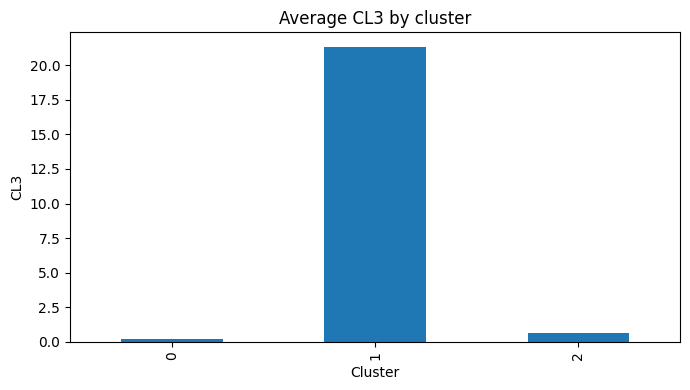

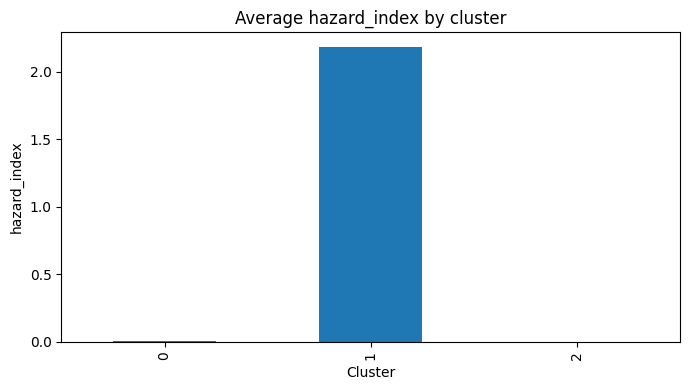

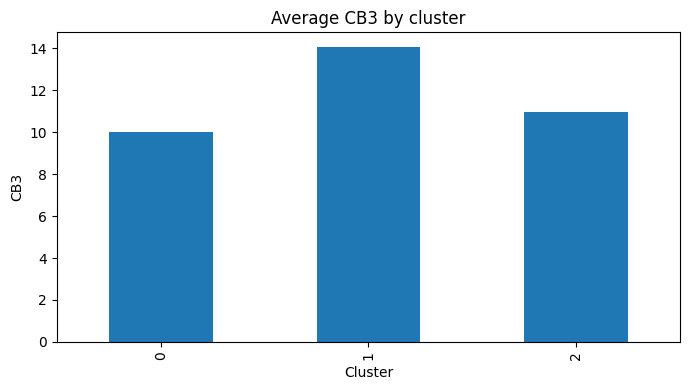

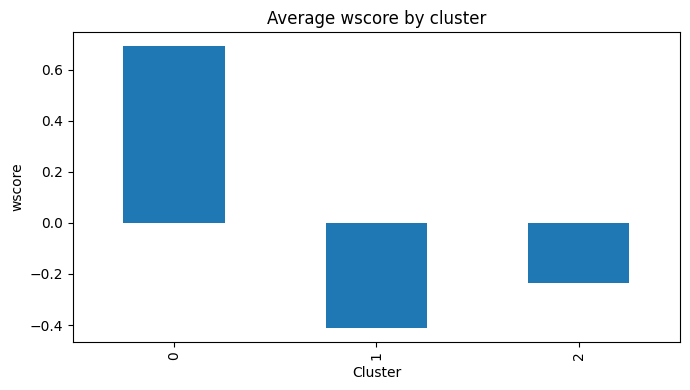

In [56]:
chart_cols = [c for c in ["CL3", "hazard_index", "CB3", "wscore"] if c in df_clustered.columns]

for col in chart_cols:
    means = df_clustered.groupby("cluster")[col].mean()
    plt.figure(figsize=(7, 4))
    means.plot(kind="bar")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.title(f"Average {col} by cluster")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"bar_{col}_by_cluster.png", dpi=200)
    plt.show()

## 16. final interpretation 



In [57]:
print("Done.")
print("All outputs saved to:", OUTPUT_DIR)
print("Main files:")
for name in [
    "profile_cards.csv",
    "cluster_model_scores.csv",
    "cluster_numeric_summary.csv",
    "cluster_weighted_summary.csv",
    "policy_bubble_chart.png",
    "cluster_pca.png",
    "top_cluster_drivers.csv",
    "feature_labels.csv"
]:
    print("-", OUTPUT_DIR / name)

Done.
All outputs saved to: /Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana/outputs_selected_features
Main files:
- /Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana/outputs_selected_features/profile_cards.csv
- /Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana/outputs_selected_features/cluster_model_scores.csv
- /Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana/outputs_selected_features/cluster_numeric_summary.csv
- /Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana/outputs_selected_features/cluster_weighted_summary.csv
- /Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana/outputs_selected_features/policy_bubble_chart.png
- /Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana/outputs_selected_features/cluster_pca.png
- /Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana/outputs_selected_features/top_cluster_drivers.csv
- /Users/lmylmy/Desktop/Crowdsourcing and AI/mini-class/Ghana/outputs_selected_features/featur